# Symbolic Regression: Synthetic Training + Feynman Benchmark

Train on synthetic univariate expressions, benchmark against Feynman equations.

In [51]:
# Environment setup — works on both Colab and local
import os, sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # Clone repo if not already present
    REPO_DIR = '/content/drive/MyDrive/Symba/sym'
    if not os.path.exists(REPO_DIR):
        %cd /content/drive/MyDrive/Symba
        !git clone https://github.com/zzpDavid2/symbolic-jepa.git {REPO_DIR}
    os.chdir(REPO_DIR)
    sys.path.insert(0, REPO_DIR)

    !pip install -q sympy scipy

    # Checkpoint dir on Drive for persistence
    CKPT_DIR = '/content/drive/MyDrive/Symba/symbolic-jepa/checkpoints/synthetic_v1'
    LOG_DIR  = '/content/drive/MyDrive/Symba/symbolic-jepa/runs'
else:
    CKPT_DIR = 'checkpoints/synthetic_v1'
    LOG_DIR  = 'runs'

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
print(f'Environment: {"Colab" if IN_COLAB else "Local"}')
print(f'Checkpoints: {CKPT_DIR}')

Environment: Local
Checkpoints: checkpoints/synthetic_v1


In [52]:
import torch
import torch.nn.functional as F
import numpy as np
import datetime
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from symbolic_jepa import (
    PrefixTokenizer, Expression, load_feynman_csv,
    TNet, SymbolicTransformer,
    PointCloudDataset, build_synthetic_splits,
    load_synthetic_pkl,
    teacher_forced_accuracy, evaluate_predictions,
)

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

Device: mps


In [53]:
if IN_COLAB:
    %cd /content/drive/MyDrive/Symba/symbolic-jepa
    !git pull

In [54]:
# ── Hyperparameters ──
MAX_VARS    = 1               # univariate synthetic data
D_INPUT     = MAX_VARS + 1    # (x, y) = 2
N_POINTS    = 1000
MAX_SEQ     = 64
D_MODEL     = 512
N_HEADS     = 8
N_LAYERS    = 4
DROPOUT     = 0.2

EPOCHS      = 30
LR          = 3e-4
BATCH       = 16
VAL_EVERY   = 1
USE_AMP     = True

# Synthetic data (pre-generated by SYMBA_Reg_Data_Gen notebook)
SYNTH_PKL   = 'data/synthetic.pkl'   # path to pickle of expression strings
MAX_SYNTH   = 10_000                    # 0 = load all
SYNTH_SEED  = 42

## Load synthetic training data

In [55]:
tokenizer = PrefixTokenizer(max_vars=MAX_VARS)
print(f'Vocab size: {len(tokenizer)}')

print(f'Loading synthetic expressions from {SYNTH_PKL}...')
synth_exprs = load_synthetic_pkl(
    SYNTH_PKL, max_seq_len=MAX_SEQ,
    tokenizer=tokenizer, max_expressions=MAX_SYNTH,
)
print(f'Loaded {len(synth_exprs)} expressions')

# Inspect a few
for expr in synth_exprs[:5]:
    print(f'  {expr.prefix}')

Vocab size: 27
Loading synthetic expressions from data/synthetic.pkl...
Loaded 9610 expressions
  mul mul C log add C pow add add add add C mul C x1 mul C pow x1 C mul C pow x1 C mul C pow x1 two two tanh add C mul C x1
  add mul mul C exp mul C pow x1 two sinh mul C x1 mul mul C pow add C mul C x1 neg1 sin add C mul C x1
  mul mul mul C cosh mul C x1 exp mul C pow x1 two exp mul C pow add C x1 two
  add mul mul C pow add C pow add C mul C x1 two neg1 add C mul C x1 mul mul C cosh mul C x1 exp mul C pow x1 two
  mul mul C pow add C mul C x1 neg1 sin add C mul C x1


/Users/zzpdavid2/Documents/GitHub/symbolic-jepa/symbolic_jepa/expressions.py:458: UserWarning: Skipped 390/10000 expressions (parse=0, tokenize=0, too_long=390, unk=0). Examples: 
  warnings.warn(


In [56]:
# Split synthetic data
synth_train, synth_val, synth_test = build_synthetic_splits(
    synth_exprs, tokenizer,
    n_points=N_POINTS, max_seq_len=MAX_SEQ, max_vars=MAX_VARS,
    seed=SYNTH_SEED,
)

Synthetic train: 7688 equations
Synthetic val: 961 equations
Synthetic test: 961 equations


## Load Feynman benchmark

In [57]:
CSV_PATH = 'data/FeynmanEquations.csv'
all_feynman = load_feynman_csv(CSV_PATH)
feynman_exprs = [e for e in all_feynman if len(e.variables) == 1]
print(f'Feynman: {len(feynman_exprs)}/{len(all_feynman)} are univariate')

feynman_bench = PointCloudDataset(
    feynman_exprs, tokenizer,
    n_points=N_POINTS, max_seq_len=MAX_SEQ, max_vars=MAX_VARS,
    resample=False,
)
print(f'Feynman benchmark: {len(feynman_bench)} equations')

Feynman: 1/100 are univariate
Feynman benchmark: 1 equations


## Build model

In [58]:
encoder = TNet(d_input=D_INPUT, d_model=D_MODEL)
model = SymbolicTransformer(
    encoder=encoder,
    vocab_size=len(tokenizer),
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    d_ff=4 * D_MODEL,
    max_seq_len=MAX_SEQ,
    dropout=DROPOUT,
    pad_id=tokenizer.pad_id,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Total parameters: {total_params:.1f}M')

Total parameters: 17.9M


/Users/zzpdavid2/Documents/GitHub/symbolic-jepa/symbolic_jepa/decoder.py:30: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)


## Training loop

In [59]:
from torch.utils.tensorboard import SummaryWriter

run_name = f"synth_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(log_dir=f'{LOG_DIR}/{run_name}')
print(f'TensorBoard: {LOG_DIR}/{run_name}')

TensorBoard: runs/synth_20260620_001937


In [60]:
CKPT_PATH = f'{CKPT_DIR}/latest.pt'
BEST_PATH = f'{CKPT_DIR}/best.pt'

train_loader = DataLoader(synth_train, batch_size=BATCH, shuffle=True,
                          num_workers=2, persistent_workers=True, pin_memory=True)
val_loader   = DataLoader(synth_val, batch_size=BATCH, shuffle=False,
                          num_workers=2, persistent_workers=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

start_epoch = 1
best_val    = float('inf')
history     = {'train': [], 'val': []}

# Resume from checkpoint if available
if os.path.exists(CKPT_PATH):
    ck = torch.load(CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ck['model'])
    optimizer.load_state_dict(ck['optimizer'])
    scheduler.load_state_dict(ck['scheduler'])
    start_epoch = ck['epoch'] + 1
    best_val    = ck['best_val']
    history     = ck['history']
    print(f'Resuming from epoch {start_epoch} (best val: {best_val:.4f})')

if USE_AMP and DEVICE == 'cuda':
    amp_ctx = lambda: torch.autocast('cuda', dtype=torch.bfloat16)
elif USE_AMP and DEVICE == 'mps':
    amp_ctx = lambda: torch.autocast('mps', dtype=torch.float16)
else:
    amp_ctx = lambda: torch.amp.autocast('cpu', enabled=False)

for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}')
    for batch in pbar:
        points    = batch['points'].to(DEVICE, non_blocking=True)
        input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        attn_mask = batch['attn_mask'].to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        with amp_ctx():
            loss = model(points, input_ids, attn_mask=attn_mask)['loss']
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        global_step = (epoch - 1) * len(train_loader) + pbar.n
        writer.add_scalar('train/loss_step', loss.item(), global_step)

    scheduler.step()
    train_avg = train_loss / len(train_loader)
    history['train'].append(train_avg)
    writer.add_scalar('train/loss_epoch', train_avg, epoch)
    writer.add_scalar('train/lr', scheduler.get_last_lr()[0], epoch)

    # Validation
    if epoch % VAL_EVERY == 0 or epoch == EPOCHS:
        model.eval()
        val_loss = 0
        val_acc  = 0
        n_val_batches = 0
        with torch.no_grad(), amp_ctx():
            for batch in val_loader:
                points    = batch['points'].to(DEVICE, non_blocking=True)
                input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
                attn_mask = batch['attn_mask'].to(DEVICE, non_blocking=True)
                out = model(points, input_ids, attn_mask=attn_mask)
                val_loss += out['loss'].item()
                val_acc  += teacher_forced_accuracy(out['logits'], input_ids, tokenizer.pad_id)
                n_val_batches += 1

        val_avg = val_loss / n_val_batches
        val_acc_avg = val_acc / n_val_batches
        history['val'].append(val_avg)
        history.setdefault('val_acc', []).append(val_acc_avg)
        writer.add_scalar('val/loss', val_avg, epoch)
        writer.add_scalar('val/token_accuracy', val_acc_avg, epoch)

        is_best = val_avg < best_val
        if is_best: best_val = val_avg
        flag = ' ★ best' if is_best else ''
        print(f'Epoch {epoch}/{EPOCHS} | train={train_avg:.4f} | val={val_avg:.4f}{flag} | val_acc={val_acc_avg*100:.1f}%')

        if is_best:
            torch.save({'model': model.state_dict(), 'epoch': epoch, 'val': val_avg}, BEST_PATH)
    else:
        print(f'Epoch {epoch}/{EPOCHS} | train={train_avg:.4f}')

    torch.save({
        'model':     model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'epoch':     epoch,
        'best_val':  best_val,
        'history':   history,
    }, CKPT_PATH)

writer.close()
print('Training complete.')

Resuming from epoch 31 (best val: 0.2068)
Training complete.


## Training curves

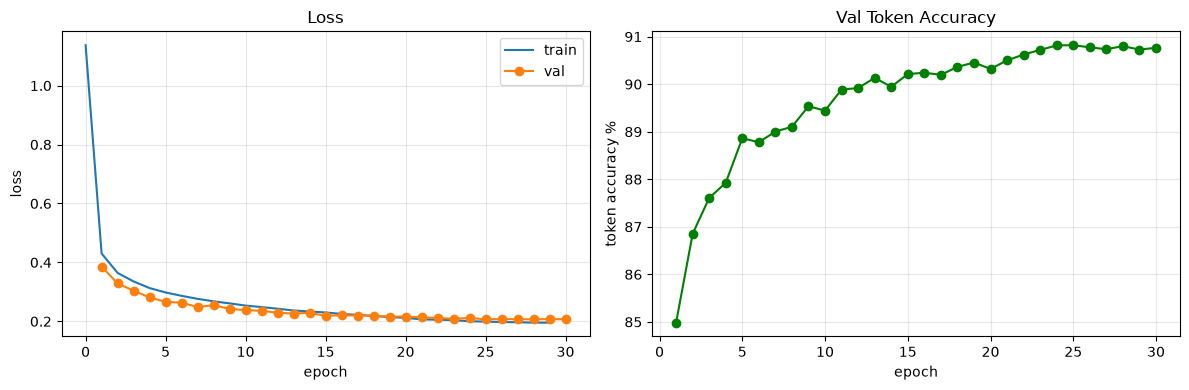

In [61]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train'], label='train')
ax1.plot(range(VAL_EVERY, len(history['train']) + 1, VAL_EVERY)[:len(history['val'])],
         history['val'], label='val', marker='o')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss')
ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title('Loss')

if 'val_acc' in history:
    ax2.plot(range(VAL_EVERY, len(history['train']) + 1, VAL_EVERY)[:len(history['val_acc'])],
             [a * 100 for a in history['val_acc']], marker='o', color='green')
    ax2.set_xlabel('epoch'); ax2.set_ylabel('token accuracy %')
    ax2.grid(alpha=0.3)
    ax2.set_title('Val Token Accuracy')

plt.tight_layout()
plt.show()

## Evaluate on synthetic test set

In [ ]:
# Load best checkpoint
if os.path.exists(BEST_PATH):
    ck = torch.load(BEST_PATH, map_location=DEVICE, weights_only=True)
    model.load_state_dict(ck['model'])
    print(f'Loaded best checkpoint (epoch {ck["epoch"]}, val={ck["val"]:.4f})')

def run_eval(dataset, name, max_eval=100, max_beam_samples=0, beam_width=5):
    """Run teacher-forced + greedy + beam eval on a dataset (capped at max_eval).

    Beam search is off by default (max_beam_samples=0). Enable with e.g.:
        run_eval(ds, 'Test', max_beam_samples=10, beam_width=5)
    """
    model.eval()
    n_eval = min(max_eval, len(dataset))

    from torch.utils.data import Subset
    eval_ds = Subset(dataset, range(n_eval))
    loader = DataLoader(eval_ds, batch_size=BATCH, shuffle=False)

    # ── Teacher-forced accuracy (fast, single forward pass per batch) ──
    tf_acc_sum, tf_batches = 0, 0
    with torch.no_grad():
        for batch in tqdm(loader, desc=f'{name} teacher-forced'):
            points    = batch['points'].to(DEVICE)
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attn_mask'].to(DEVICE)
            out = model(points, input_ids, attn_mask=attn_mask)
            tf_acc_sum += teacher_forced_accuracy(out['logits'], input_ids, tokenizer.pad_id)
            tf_batches += 1
    tf_acc = tf_acc_sum / tf_batches
    print(f'\n── {name} Teacher-Forced (n={n_eval}) ──')
    print(f'  Token accuracy:  {tf_acc*100:.1f}%')

    # ── Greedy decode ──
    greedy_preds = []
    for batch in tqdm(loader, desc=f'{name} greedy'):
        points = batch['points'].to(DEVICE)
        input_ids = batch['input_ids']
        preds = model.generate(points, tokenizer, max_new_tokens=MAX_SEQ)
        for j, pred_str in enumerate(preds):
            gt_str = tokenizer.decode(input_ids[j].tolist())
            greedy_preds.append((gt_str, pred_str))

    greedy_results = evaluate_predictions(greedy_preds, dataset, tokenizer)
    greedy_results['teacher_forced_acc'] = tf_acc
    print(f'\n── {name} (Greedy, n={len(greedy_preds)}) ──')
    print(f'  Exact match:     {greedy_results["exact_match"]*100:.1f}%')
    print(f'  Token accuracy:  {greedy_results["token_accuracy"]*100:.1f}%')
    print(f'  Algebraic equiv: {greedy_results["algebraic_equiv"]*100:.1f}%')
    print(f'  Mean R²:         {greedy_results["mean_r2"]:.4f}')
    print(f'  R² > 0.9:        {greedy_results["r2_above_0.9"]*100:.1f}%')
    print(f'  Parseable:       {greedy_results["n_parseable"]}/{greedy_results["n_total"]}')

    # ── Beam search on subset (off by default) ──
    beam_results = None
    if max_beam_samples > 0:
        n_beam = min(max_beam_samples, n_eval)
        beam_preds = []
        for idx in tqdm(range(n_beam), desc=f'{name} beam'):
            sample = dataset[idx]
            points = sample['points'].unsqueeze(0).to(DEVICE)
            gt_str = tokenizer.decode(sample['input_ids'].tolist())
            pred = model.generate_beam(
                points, tokenizer,
                max_new_tokens=MAX_SEQ, beam_width=beam_width,
            )[0]
            beam_preds.append((gt_str, pred))

        beam_results = evaluate_predictions(beam_preds, dataset, tokenizer)
        print(f'\n── {name} (Beam w={beam_width}, n={n_beam}) ──')
        print(f'  Exact match:     {beam_results["exact_match"]*100:.1f}%')
        print(f'  Token accuracy:  {beam_results["token_accuracy"]*100:.1f}%')
        print(f'  Algebraic equiv: {beam_results["algebraic_equiv"]*100:.1f}%')
        print(f'  Mean R²:         {beam_results["mean_r2"]:.4f}')
        print(f'  R² > 0.9:        {beam_results["r2_above_0.9"]*100:.1f}%')

    return greedy_results, beam_results

In [63]:
synth_greedy, synth_beam = run_eval(synth_test, 'Synthetic Test')

Synthetic Test greedy: 100%|██████████| 7/7 [00:17<00:00,  2.50s/it]



── Synthetic Test (Greedy, n=100) ──
  Exact match:     16.0%
  Token accuracy:  36.4%
  Algebraic equiv: 16.0%
  Mean R²:         -inf
  R² > 0.9:        26.0%
  Parseable:       100/100


Synthetic Test beam: 100%|██████████| 50/50 [03:55<00:00,  4.72s/it]
/opt/anaconda3/envs/symba/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]



── Synthetic Test (Beam w=10, n=50) ──
  Exact match:     24.0%
  Token accuracy:  39.1%
  Algebraic equiv: 24.0%
  Mean R²:         -inf
  R² > 0.9:        40.0%


## Benchmark on Feynman equations

In [64]:
feyn_greedy, feyn_beam = run_eval(feynman_bench, 'Feynman Benchmark')

Feynman Benchmark greedy: 100%|██████████| 1/1 [00:00<00:00,  2.03it/s]



── Feynman Benchmark (Greedy, n=1) ──
  Exact match:     0.0%
  Token accuracy:  3.6%
  Algebraic equiv: 0.0%
  Mean R²:         0.9999
  R² > 0.9:        100.0%
  Parseable:       1/1


Feynman Benchmark beam: 100%|██████████| 1/1 [00:03<00:00,  3.20s/it]


── Feynman Benchmark (Beam w=10, n=1) ──
  Exact match:     0.0%
  Token accuracy:  5.6%
  Algebraic equiv: 0.0%
  Mean R²:         0.8749
  R² > 0.9:        0.0%


## Inspect predictions

In [65]:
# Show a few predictions from each test set
for name, results in [('Synthetic', synth_greedy), ('Feynman', feyn_greedy)]:
    if results is None:
        continue
    print(f'\n═══ {name} predictions (first 10) ═══')
    for d in results['details'][:10]:
        print(f'  GT:   {d["gt"]}')
        print(f'  Pred: {d["pred"]}')
        r2_str = f'{d["r2"]:.4f}' if d['r2'] is not None else 'N/A'
        print(f'  R²:   {r2_str}  | exact={bool(d["exact"])}')
        print()


═══ Synthetic predictions (first 10) ═══
  GT:   mul mul C cosh mul C x1 exp mul C pow x1 two
  Pred: mul mul C cosh mul C x1 exp mul C pow x1 two
  R²:   1.0000  | exact=True

  GT:   mul C log add C pow add C mul C x1 two
  Pred: add add add C mul C log add C pow add add C mul C pow x1 two mul C x1 two mul C x1 mul C pow x1 two mul C pow add C mul C x1 neg1 sin add C mul C x1
  R²:   0.9999  | exact=False

  GT:   add mul C exp mul C pow add C x1 two mul C log add C pow add add C mul C pow x1 two mul C x1 two
  Pred: mul mul C pow add C pow add add add C mul C pow x1 C mul C pow x1 two mul C x1 two neg1 add add add add C mul C pow x1 C mul C pow x1 C mul C x1 mul C pow x1 two
  R²:   -inf  | exact=False

  GT:   add mul mul C cosh mul C x1 exp mul C pow x1 two mul mul C pow add C mul C x1 neg1 sin add C mul C x1
  Pred: add mul C exp mul C pow add C x1 two mul mul C pow add C mul C x1 neg1 sin add C mul C x1
  R²:   0.9980  | exact=False

  GT:   mul C exp mul C pow add C x1 two
  P